# COVID-19 Data Analysis: Exploring Trends, Vaccination Impact, and Insights Through Visualizations

The COVID-19 pandemic, caused by the SARS-CoV-2 virus, has significantly impacted global health, economies, and daily life. Since its emergence in late 2019, vast amounts of data have been collected on infection rates, mortality, vaccination efforts, and testing strategies. Analyzing this data is crucial for understanding the spread of the virus, identifying trends, and making informed policy decisions. This project involves basic data cleaning, exploratory data analysis (EDA), and visualization to uncover insights into COVID-19 cases, deaths, and vaccinations over time.

## About the Dataset

The **[dataset](https://drive.google.com/file/d/1syeD6Ni_ZlfXHHH0Jp6ALpvg9iCAEk_-/view?usp=sharing)** used for this project contains essential COVID-19 metrics, tracking the progression of the pandemic across different countries. The dataset consists of the following columns:

- DATE: The recorded date of COVID-19 data entry.
- country: The country or region where the cases, deaths, and vaccinations were reported.
- NEW Cases: The number of newly confirmed COVID-19 cases reported on a given date.
- NEW_DEATHS: The number of new deaths attributed to COVID-19 on that specific date.
- vaccinated: The number of people who have received at least one dose of the COVID-19 vaccine.

This dataset may require cleaning and preprocessing to handle missing values, incorrect formats, and inconsistencies before conducting meaningful analysis.

## Objective

The primary goal of this mini-project is to clean, analyze, and visualize COVID-19 data to identify trends, patterns, and key insights. The specific objectives include:

- Perform Data Cleaning: Handle missing values, standardize date formats, and filter out inconsistencies.
- Explore Trends in COVID-19 Cases and Deaths:
  - Analyze daily and cumulative trends in infections and fatalities.
  - Compare case and death rates across different countries and regions.
- Create Data Visualizations:
  - Line Plots: Show the trend of cases, deaths, and vaccinations over time.
  - Bar Charts: Compare cases, deaths, and vaccinations by country.
  - Scatter Plots: Explore relationships between infection rates and testing or vaccination rates.

### Module Importation

In [1]:
# importing all necessary modules
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read the csv file
covid_df = pd.read_csv(r'COVID data.csv')
""" This reads in the csv file needed for analysis """
covid_df

,DATE,country,NEW Cases,NEW_DEATHS,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
...,...,...,...,...,...
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438
162,2024-11-30,Canada,1133.0,56.0,438
163,2024-11-30,China,0.0,0.0,unknown


### Data Cleaning

In [3]:
covid_df.duplicated().sum()

15

In [4]:
covid_df.drop_duplicates(inplace = True)
covid_df

,DATE,country,NEW Cases,NEW_DEATHS,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
5,2024-11-01,China,1034.0,51.0,462
...,...,...,...,...,...
158,2024-11-30,Argentina,1619.0,80.0,unknown
159,2024-11-30,Australia,1473.0,73.0,428
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438


In [5]:
covid_df.dtypes

DATE            object
country         object
 NEW Cases     float64
NEW_DEATHS     float64
vaccinated      object
dtype: object

In [6]:
covid_df.isnull().sum()

DATE            0
country         0
 NEW Cases     11
NEW_DEATHS     25
vaccinated      0
dtype: int64

In [7]:
covid_df.fillna(0.0, inplace = True)

In [8]:
covid_df.columns

Index(['DATE ', 'country ', ' NEW Cases', 'NEW_DEATHS', 'vaccinated '], dtype='object')

In [9]:
# rename the columns to have consistent cases
covid_df.rename(columns= {'DATE ': 'Date',
                          'country ': 'Country',
                          ' NEW Cases': 'New_cases',
                          'NEW_DEATHS': 'New_deaths', 
                          'vaccinated ':'Vaccinated' }, 
                inplace= True)

In [10]:
covid_df['Vaccinated'].replace({'unknown':'0'}, inplace=True)

In [11]:
covid_df.nunique()

Date           42
Country         5
New_cases     124
New_deaths     61
Vaccinated    117
dtype: int64

In [12]:
# Srandardize the date column 
covid_df['Date'] = pd.to_datetime(covid_df['Date'])
covid_df

,Date,Country,New_cases,New_deaths,Vaccinated
0,2024-11-01,Argentina,0.0,0.0,0
1,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,0
5,2024-11-01,China,1034.0,51.0,462
...,...,...,...,...,...
158,2024-11-30,Argentina,1619.0,80.0,0
159,2024-11-30,Australia,1473.0,73.0,428
160,2024-11-30,Brazil,514.0,25.0,0
161,2024-11-30,Canada,1133.0,56.0,438


In [13]:
covid_df['Vaccinated']= covid_df['Vaccinated'].astype(int)

### Exploratory Data Analysis

In [14]:
# Grouping cases by countries
arg_cty = covid_df[covid_df['Country'] == 'Argentina']
aus_cty = covid_df[covid_df['Country'] == 'Australia']
bra_cty = covid_df[covid_df['Country'] == 'Brazil']
can_cty = covid_df[covid_df['Country'] == 'Canada']
chi_cty = covid_df[covid_df['Country'] == 'China']

""" This isolates the data that are from each countries and stores them in a specific dataframe"""

' This isolates the data that are from each countries and stores them in a specific dataframe'

' This shows the trend of cases per day in each country '

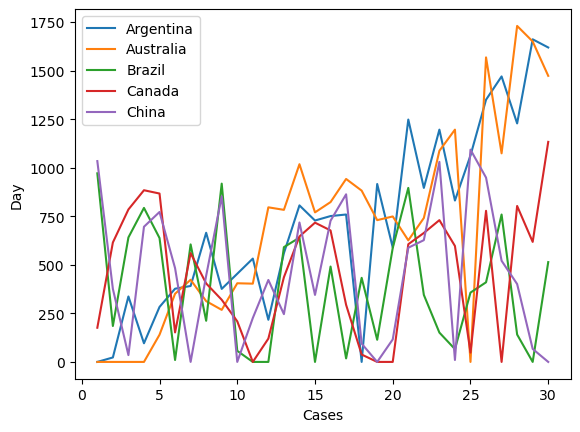

In [15]:
# Visualize the daily trends of infections in each city
plt.figure()
plt.plot(arg_cty['Date'].dt.day, arg_cty['New_cases'], label = 'Argentina')
plt.plot(aus_cty['Date'].dt.day, aus_cty['New_cases'], label = 'Australia')
plt.plot(bra_cty['Date'].dt.day, bra_cty['New_cases'], label = 'Brazil')
plt.plot(can_cty['Date'].dt.day, can_cty['New_cases'], label = 'Canada')
plt.plot(chi_cty['Date'].dt.day, chi_cty['New_cases'], label = 'China')

plt.xlabel('Cases')
plt.ylabel('Day')
plt.legend()
""" This shows the trend of cases per day in each country """

' This shows the trend of deaths per day in each country '

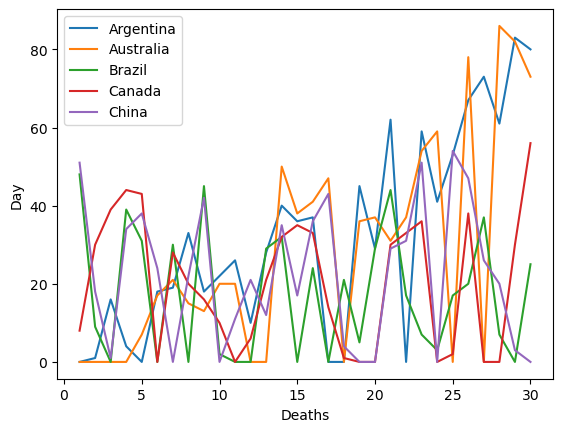

In [16]:
# Visualize the daily trends of fatalities in each city
plt.figure()
plt.plot(arg_cty['Date'].dt.day, arg_cty['New_deaths'], label = 'Argentina')
plt.plot(aus_cty['Date'].dt.day, aus_cty['New_deaths'], label = 'Australia')
plt.plot(bra_cty['Date'].dt.day, bra_cty['New_deaths'], label = 'Brazil')
plt.plot(can_cty['Date'].dt.day, can_cty['New_deaths'], label = 'Canada')
plt.plot(chi_cty['Date'].dt.day, chi_cty['New_deaths'], label = 'China')

plt.xlabel('Deaths')
plt.ylabel('Day')
plt.legend()

""" This shows the trend of deaths per day in each country """

<Axes: xlabel='New_cases', ylabel='New_deaths'>

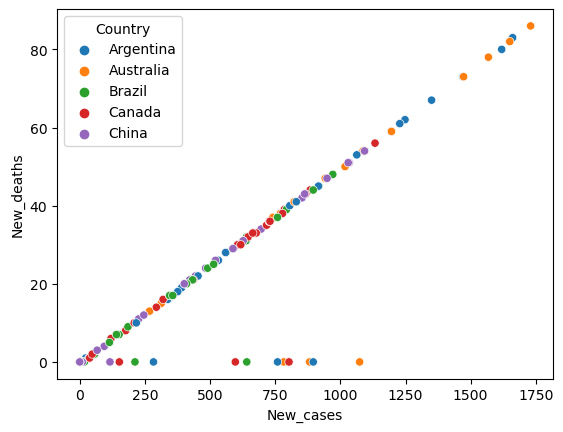

In [17]:
sns.scatterplot(data= covid_df, x=covid_df['New_cases'], y=covid_df['New_deaths'], hue='Country')

The above visualisation shows that most of the cases led to death across all countries

<Axes: xlabel='Date', ylabel='Vaccinated'>

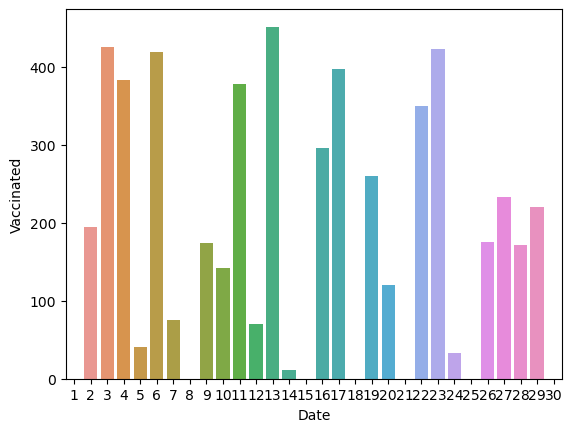

In [27]:
#Vaccination rate in each country
sns.barplot(data= arg_cty, x= arg_cty['Date'].dt.day, y= arg_cty['Vaccinated'])

<Axes: xlabel='Date', ylabel='Vaccinated'>

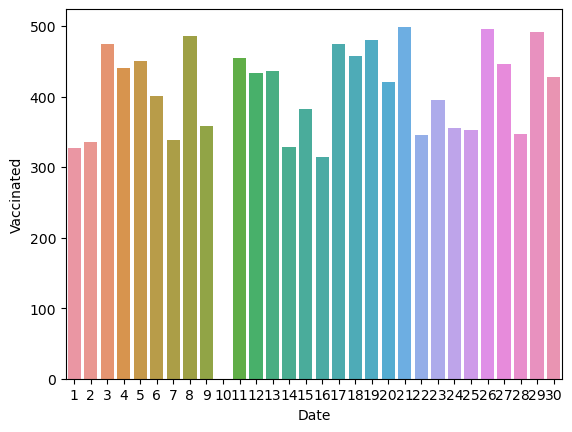

In [19]:
sns.barplot(data= aus_cty, x= aus_cty['Date'].dt.day, y= covid_df['Vaccinated'])

<Axes: xlabel='Date', ylabel='Vaccinated'>

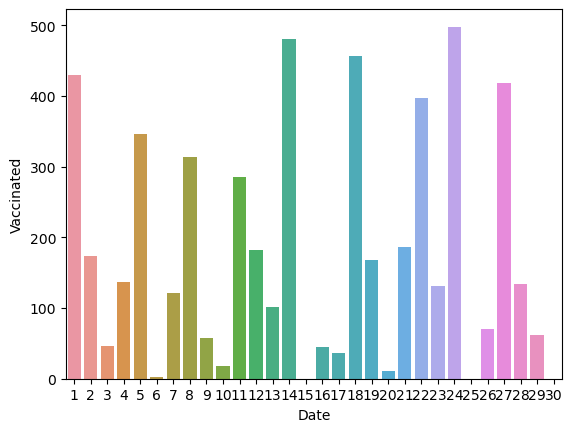

In [20]:
sns.barplot(data= bra_cty, x= bra_cty['Date'].dt.day, y= covid_df['Vaccinated'])

<Axes: xlabel='Date', ylabel='Vaccinated'>

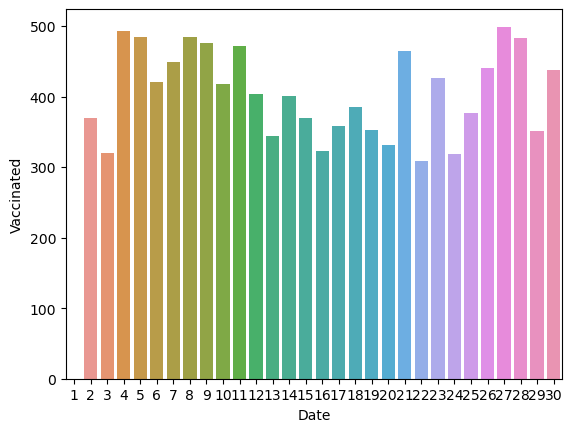

In [21]:
sns.barplot(data= can_cty, x= can_cty['Date'].dt.day, y= covid_df['Vaccinated'])

<Axes: xlabel='Date', ylabel='Vaccinated'>

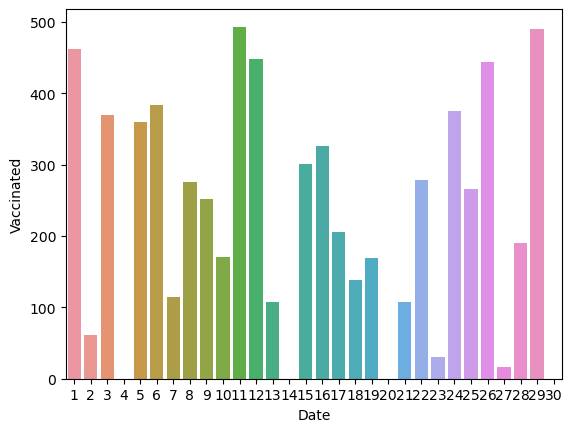

In [22]:
sns.barplot(data= chi_cty, x= chi_cty['Date'].dt.day, y= covid_df['Vaccinated'])

In [23]:
# Total Vaccination in each countries
vac = covid_df.groupby('Country')['Vaccinated'].sum().reset_index()
vac

,Country,Vaccinated
0,Argentina,5438
1,Australia,11948
2,Brazil,5309
3,Canada,11762
4,China,6833


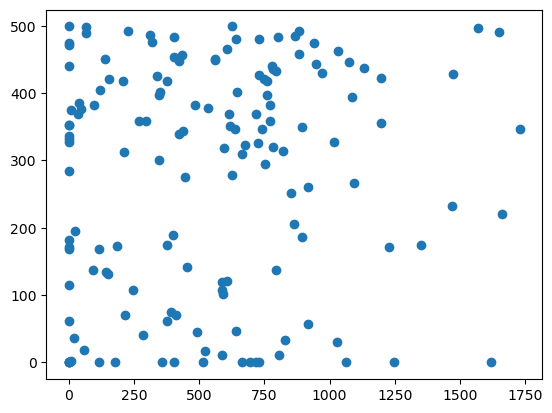

In [24]:
# The rate of infection vs vaccination rate
plt.scatter(covid_df['New_cases'], covid_df['Vaccinated'])

The correlation between infection rate and vaccination rate is low, which shows that one is not dependent on the other

In [25]:
covid_df.corr()

C:\Users\pc\AppData\Local\Temp\ipykernel_3680\560756405.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  covid_df.corr()


,New_cases,New_deaths,Vaccinated
New_cases,1.000000,0.899009,0.109749
New_deaths,0.899009,1.000000,0.041818
Vaccinated,0.109749,0.041818,1.000000
